5. EXPLICABILIDAD CON SHAP
- El objetivo de esta sección es explicar las predicciones del RSF a nivel individual, identificando las variables que impulsan el riesgo de cada paciente, para arriba o para abajo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

# Carga y preparación de los datos
luad = pd.read_csv("../data/tcga_luad_modelo.csv")
luad["estadio_num"] = luad["estadio"].map({"I":1, "II":2, "III":3, "IV":4})
luad["sexo_hombre"] = (luad["sexo"] == "Hombre").astype(int)
luad["n_positivo"]  = (luad["ajcc_pathologic_n"].isin(["N1","N2","N3"])).astype(int)
luad["m_positivo"]  = (luad["ajcc_pathologic_m"].isin(["M1","M1a","M1b"])).astype(int)
luad = luad.dropna(subset=["estadio_num", "age_at_index"]).copy()

X = luad[["estadio_num", "age_at_index", "sexo_hombre", "n_positivo", "m_positivo"]]
y = Surv.from_arrays(event=luad["evento"].astype(bool), time=luad["tiempo_anios"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Reentrenar el RSF
rsf = RandomSurvivalForest(n_estimators=100, min_samples_leaf=10,
                            max_features="sqrt", random_state=42, n_jobs=-1)
rsf.fit(X_train, y_train)

# Estos serán los pacientes con los que hagamos las descomposiciones y comparaciones
print("Modelo entrenado. Pacientes en test:", len(X_test))

c:\Users\leire.rolo\tcga-luad-survival\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo entrenado. Pacientes en test: 115


In [ ]:
# Calcular los valores SHAP
#se puede usar una muestra de los pacientes, pero yo voy a hacerlo con todos, para que refleje mejor la realidad
background = shap.sample(X_train, 50)

explainer = shap.KernelExplainer(
    lambda x: rsf.predict(pd.DataFrame(x, columns=X_train.columns)),
    background
)

#calculo SHAP solo sobre todos pacientes del test
shap_values = explainer.shap_values(X_test)

#nombres para las variables
feature_names = ["Estadio", "Edad", "Sexo (Hombre)", "Ganglios (N+)", "Metástasis (M+)"]

print("SHAP values calculados.")
print(f"Shape: {shap_values.shape}")

100%|██████████| 115/115 [00:27<00:00,  4.20it/s]

SHAP values calculados.
Shape: (115, 5)


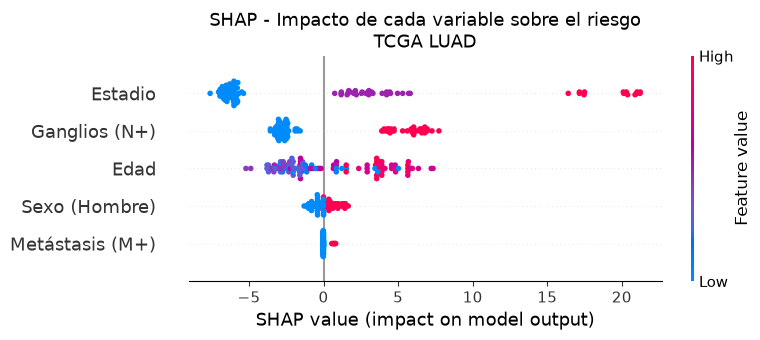

In [7]:
#5.1. BEESWARM PLOT: Impacto global de cada variable sobre el riesgo
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP - Impacto de cada variable sobre el riesgo\nTCGA LUAD", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

Paciente de mayor riesgo predicho:
Estadio             3.0
Edad               72.0
Sexo (Hombre)       1.0
Ganglios (N+)       1.0
Metástasis (M+)     0.0
Name: 145, dtype: float64


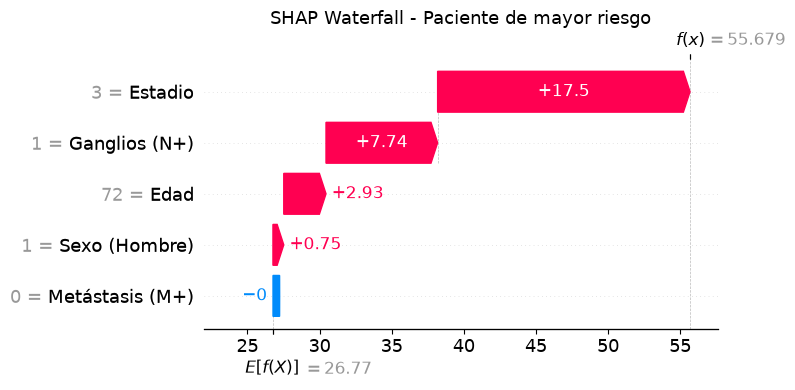

In [8]:
#5.2. WATERFALL PLOT: explicación individual del paciente de mayor riesgo predicho
riesgos = rsf.predict(X_test)
idx_mayor_riesgo = np.argmax(riesgos)

print("Paciente de mayor riesgo predicho:")
print(X_test.iloc[idx_mayor_riesgo].rename({
    "estadio_num": "Estadio",
    "age_at_index": "Edad",
    "sexo_hombre": "Sexo (Hombre)",
    "n_positivo": "Ganglios (N+)",
    "m_positivo": "Metástasis (M+)"
}))

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx_mayor_riesgo],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx_mayor_riesgo].values,
        feature_names=feature_names
    ),
    show=False
)
plt.title("SHAP Waterfall - Paciente de mayor riesgo", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

Paciente de MENOR riesgo predicho:
Estadio             1.0
Edad               69.0
Sexo (Hombre)       1.0
Ganglios (N+)       0.0
Metástasis (M+)     0.0
Name: 143, dtype: float64
Riesgo predicho: 13.50

Riesgo predicho mayor: 55.68


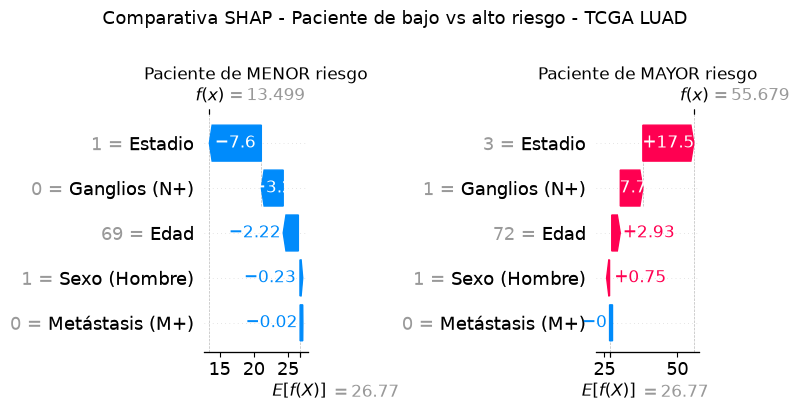

In [11]:
#5.3. COMPARATIVA DE 2 PACIENTES: mayor vs menor riesgo
idx_menor_riesgo = np.argmin(riesgos)

print("Paciente de MENOR riesgo predicho:")
print(X_test.iloc[idx_menor_riesgo].rename({
    "estadio_num": "Estadio",
    "age_at_index": "Edad",
    "sexo_hombre": "Sexo (Hombre)",
    "n_positivo": "Ganglios (N+)",
    "m_positivo": "Metástasis (M+)"
}))

print(f"Riesgo predicho: {riesgos[idx_menor_riesgo]:.2f}")
print()
print(f"Riesgo predicho mayor: {riesgos[idx_mayor_riesgo]:.2f}")

fig, axes = plt.subplots(1,2,figsize=(16,5))

for ax, idx, titulo in [
    (axes[0], idx_menor_riesgo, "Paciente de MENOR riesgo"),
    (axes[1], idx_mayor_riesgo, "Paciente de MAYOR riesgo")
]:
    plt.sca(ax)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx].values,
            feature_names=feature_names
        ),
        show=False
    )
    ax.set_title(titulo, fontsize=12)

plt.suptitle("Comparativa SHAP - Paciente de bajo vs alto riesgo - TCGA LUAD", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/shap_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()